# Shor syndrome measurement

This notebook shows how to perform Shor-style syndrome measurement.

First, we load a fault-tolerant CAT state preparation circuit:

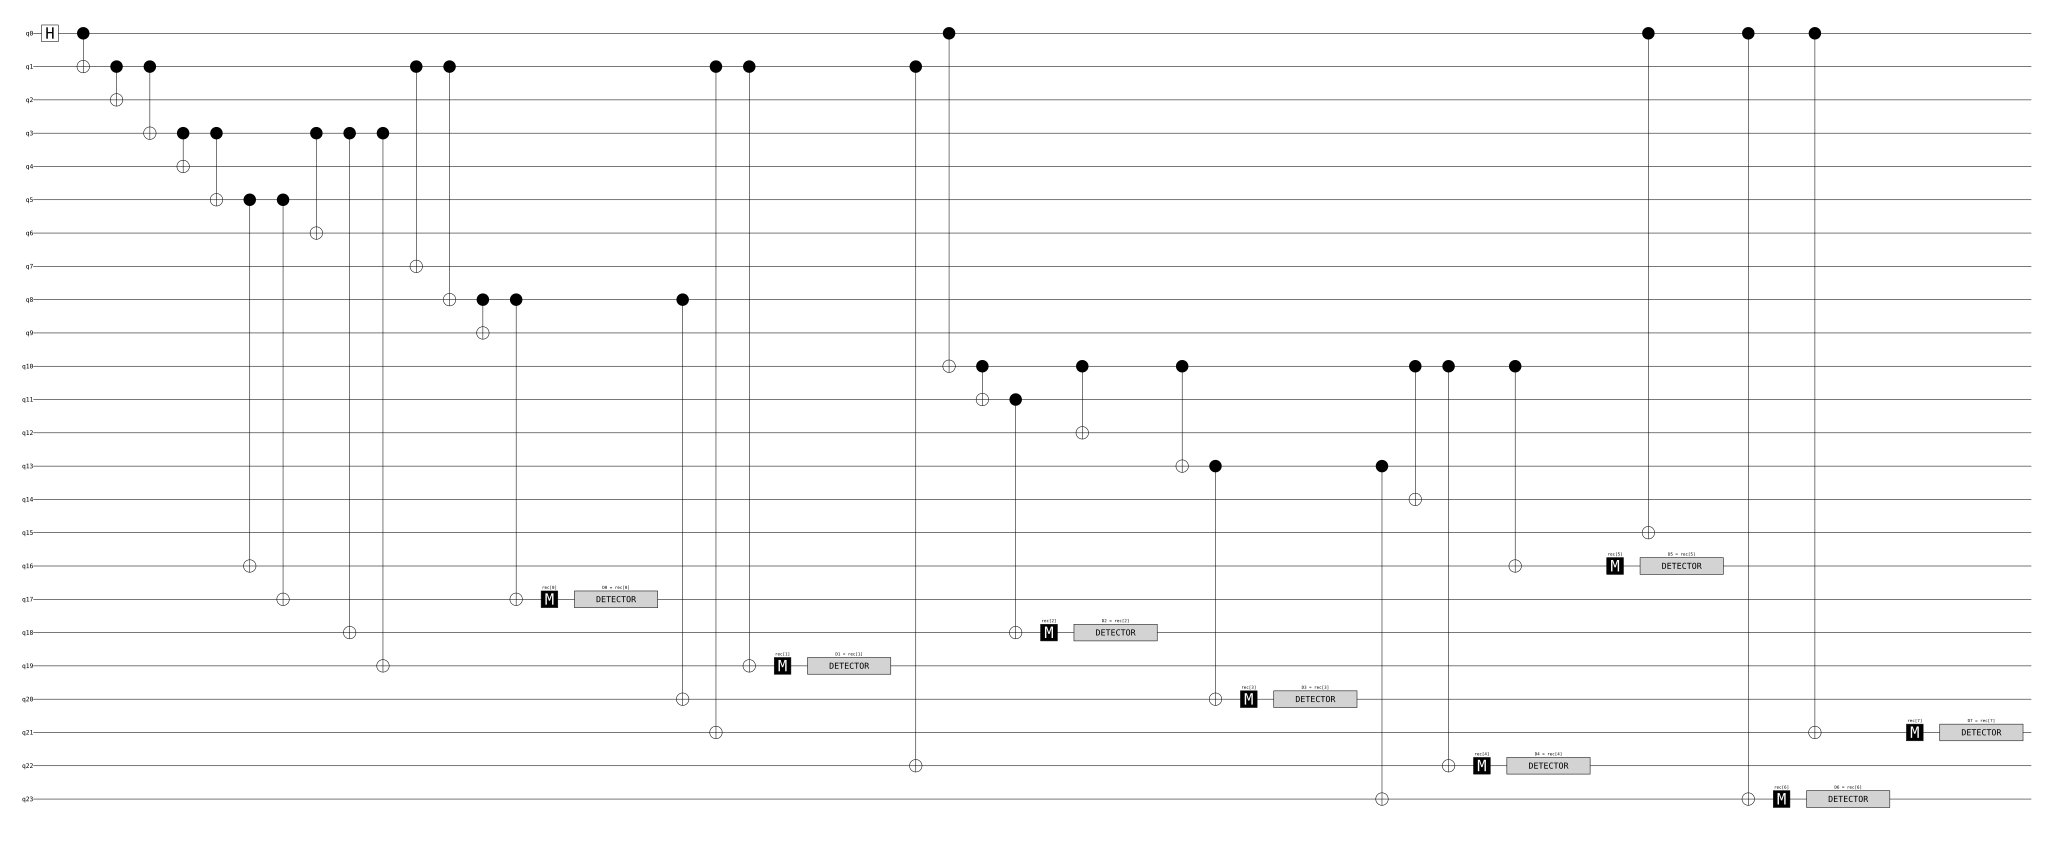

In [11]:
import stim
from spidercat.utils import load_stim_circuit, offset_circuit_by, flatten

N = 16
d = 8
t = d // 2

cat_state = load_stim_circuit(n=N, t=t)
cat_state.diagram('timeline-svg')

Next, we perform transversal gates and measure the qubits. The syndrome corresponds to the sum of the measurement outcomes.

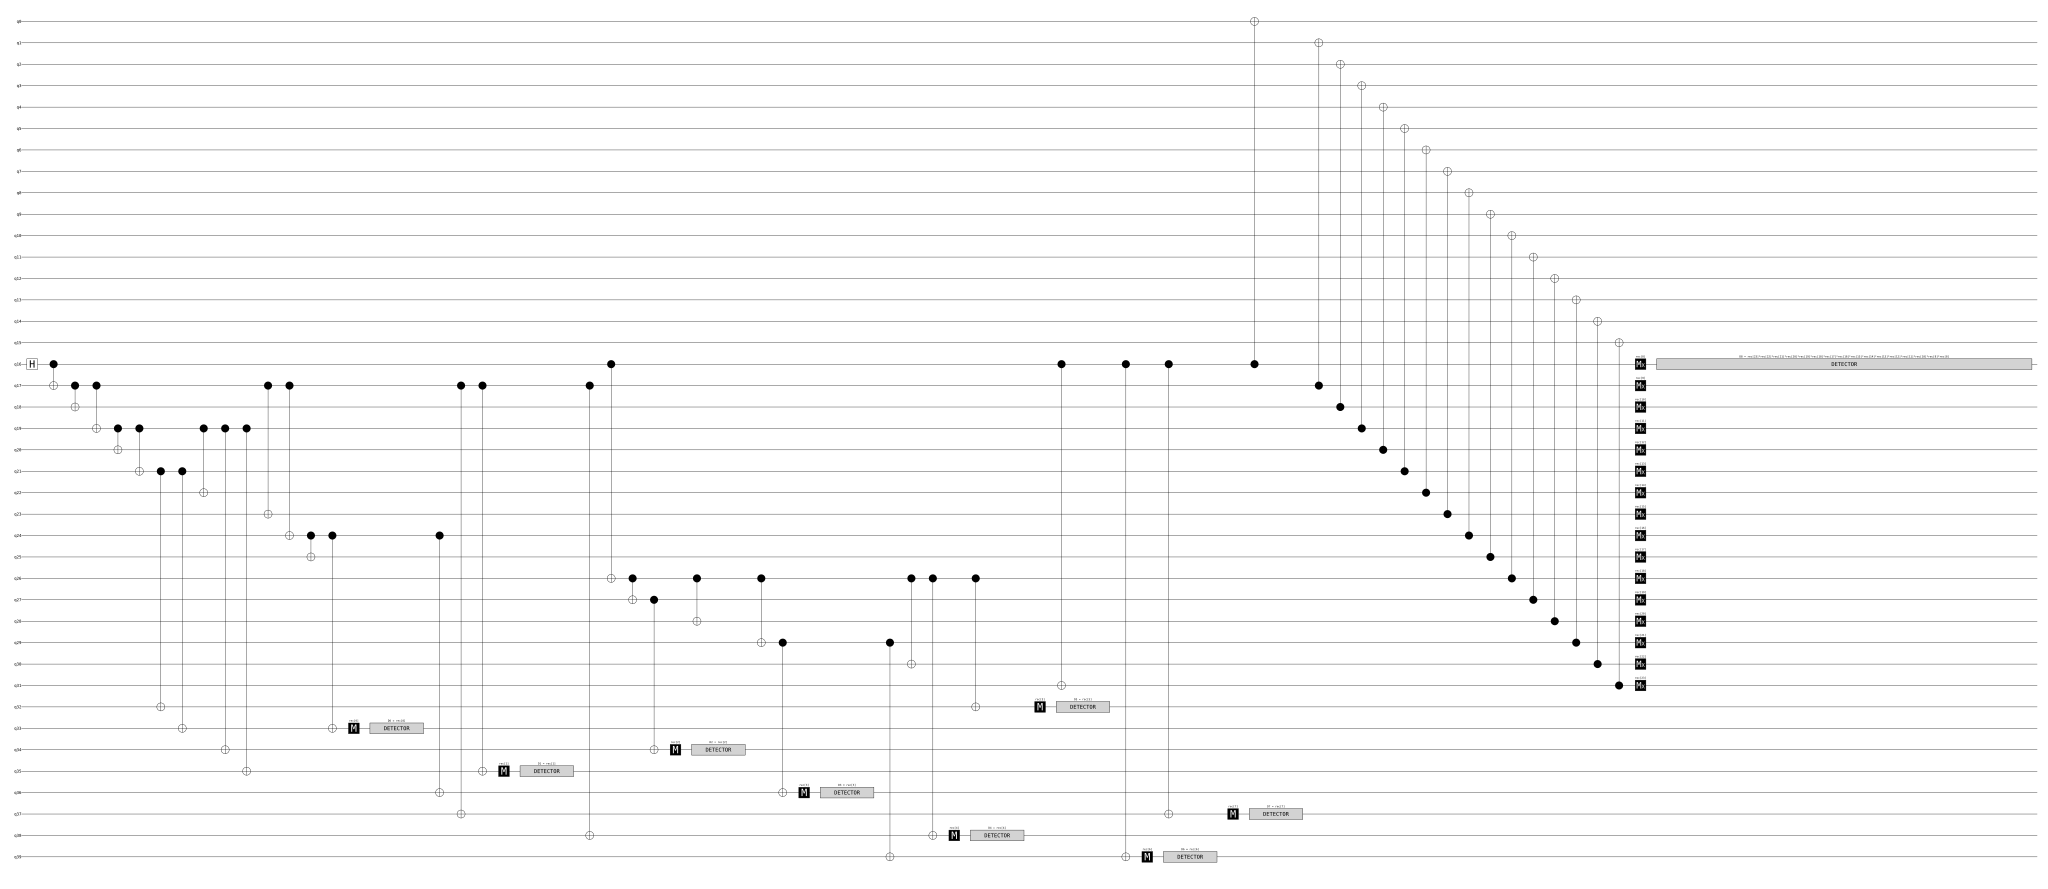

In [14]:
shor_measurement_circuit = offset_circuit_by(cat_state, N)
shor_measurement_circuit.append("CX", flatten(zip(range(N, 2 * N), range(N))))
shor_measurement_circuit.append("MX", range(N, 2 * N))
shor_measurement_circuit.append("DETECTOR", [stim.target_rec(-i - 1) for i in range(N)])
shor_measurement_circuit.diagram('timeline-svg')

Note that this is not fully fault-tolerant, as measurement errors can happen. This needs to be repeated $t + 1 = (d + 1) / 2$ times:

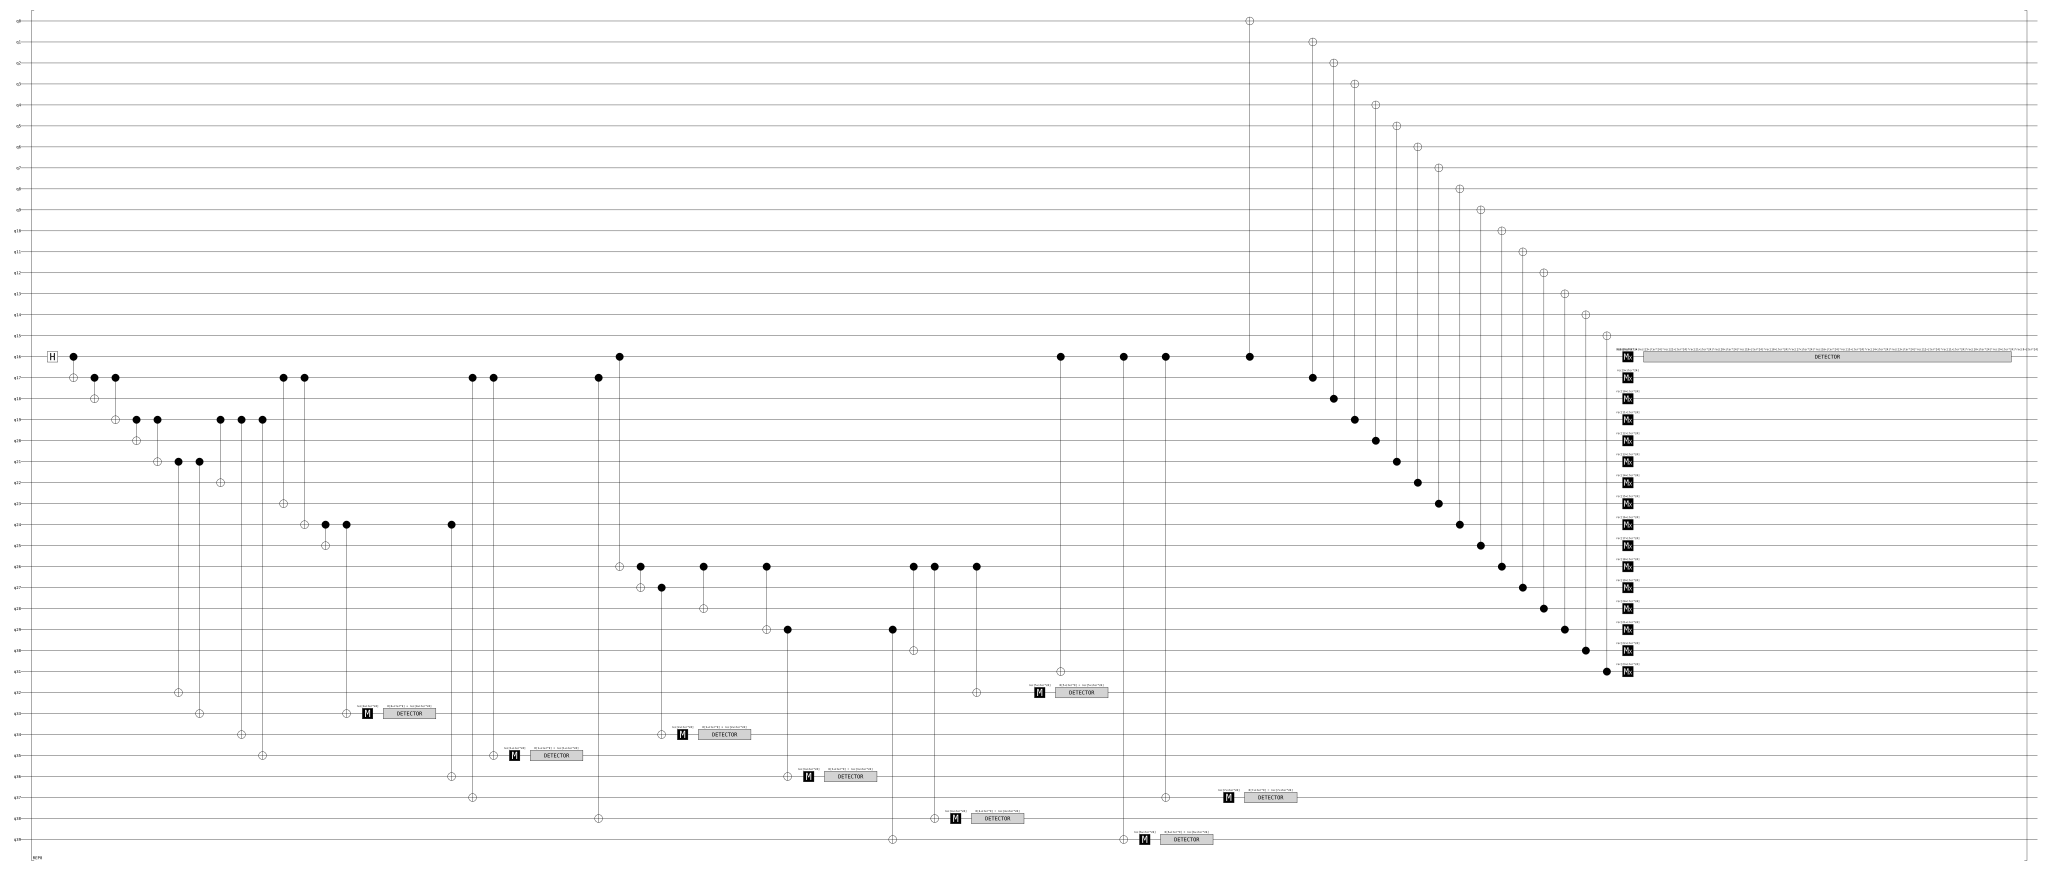

In [13]:
shor_syndrome_measurement = shor_measurement_circuit * (t + 1)
shor_syndrome_measurement.diagram('timeline-svg')

Also note that the detectors in the above circuit are not done appropriately. There should be detectors between consecutive measurements, as well as detectors between different QEC cycles.